# Algo 3: Unified Inference with Disentangled Rejection
# Experiment: 4 Classes
## BoT-IoT | Day-23 FROZEN Checkpoint | Recalibrate q | Analytic $L_\varphi$ (R/2)
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import json
from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_BATCH_SIZE, DEFAULT_CF,
    DEFAULT_NOISE_RATE, ZERO_DAY, DEFAULT_SEED,
)
from scripts.data import (
    capped_sample, load_split, to_angles,
    plot_class_balance_pie, stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import calibrate_threshold
from scripts.logging import write_history_log
from scripts.inference import qsnet_infer_batch
from scripts.utils import get_torch_device, to_np_y
from scripts.theory import analytic_lipschitz_bound

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Config

In [4]:
NOTEBOOK_NAME = "4class-3000each-lr0.05-algo3"
DAY23_NOTEBOOK = "4class-3000each-lr0.05-maqt"

dataset = "BoT-IoT"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

SEED = 42


## Load Team C's FROZEN Features

In [5]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: QIGPSO
k=10 features: ['n_pkts_total', 'n_bytes_total', 'src_bytes', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'pkt_size_std', 'protocol', 'conn_state']


## Load Team A's FROZEN Dataset

In [6]:
# load all data
X_train_full, y_train_full, class_names, df_train = load_split(
    data_path, f"train", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_cal_full, y_cal_full, _, df_cal = load_split(
    data_path, f"calibration", target_col, categories=class_names, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_test_full, y_test_full, _, df_test = load_split(
    data_path, f"test", target_col, categories=class_names, csv=True, selected_cols=FEATURE_COLS, return_df=True
)
X_zero_full, y_zero_full, _, df_zero = load_split(
    data_path, f"zeroday", target_col, categories=None, csv=True, selected_cols=FEATURE_COLS, return_df = True  # categories must be None for zeroday set
)

# check shape
print(f"train   : {X_train_full.shape, y_train_full.shape}\n\
cal     : {X_cal_full.shape, y_cal_full.shape}\n\
test    : {X_test_full.shape, y_test_full.shape}\n\
zero    : {X_zero_full.shape, y_zero_full.shape}\n\
classes : {class_names}\n"
)

df_train.head(3)

train   : ((148729, 10), (148729,))
cal     : ((18591, 10), (18591,))
test    : ((18591, 10), (18591,))
zero    : ((683, 10), (683,))
classes : ['DDoS', 'DoS', 'Normal', 'Reconnaissance']



,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,-0.262256,-0.798644,-0.774964,-0.356930,0.000000,0.123458,-0.266091,0.827772,0.0,0.0,DoS
1,0.427561,-0.121016,0.000000,-0.123704,0.000000,0.120431,0.030826,0.766490,0.0,0.0,DoS
2,0.768961,0.200956,0.368220,1.725276,0.761987,0.244690,0.422755,0.618673,0.0,0.0,DDoS


## EDA (Before Subset)

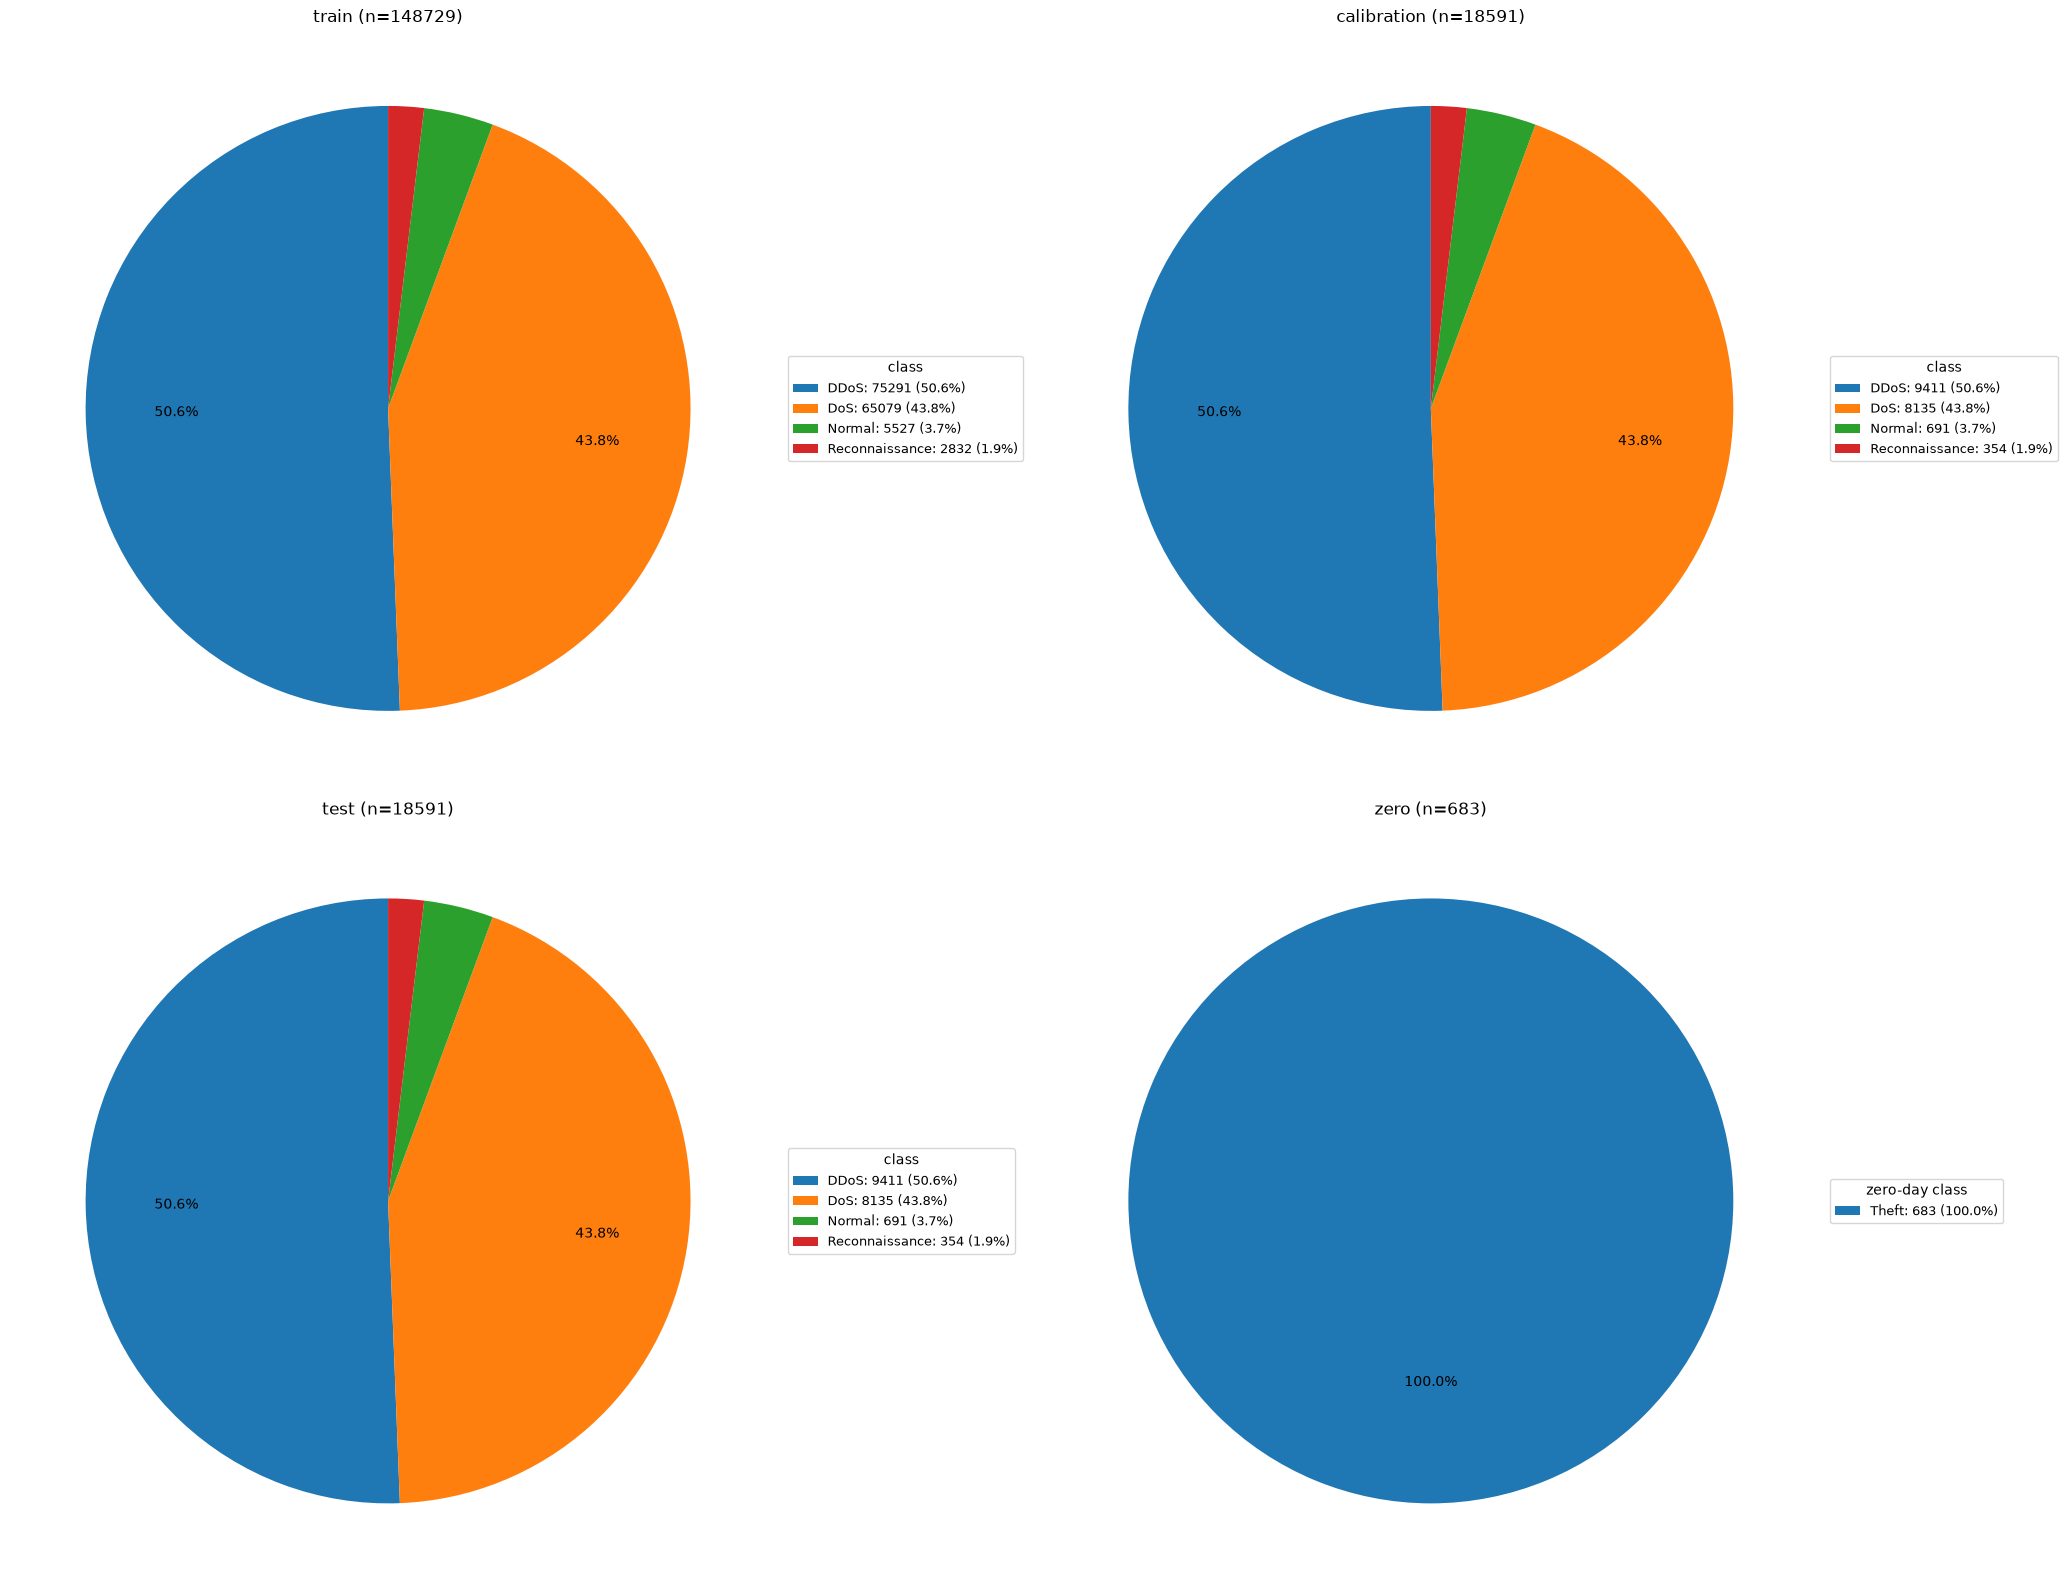

In [7]:
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

vc = df_zero[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

# remove extra chart if exists
for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Data Subset (Optional)

In [8]:
SUBSET = True       # set to False for the full known splits
MORE_SUBSET = False  # set to True for smaller cal/test/zero to make a quick pass
PER_CLASS_CAP = 3000

In [9]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

if MORE_SUBSET is True:
    X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 400, seed=SEED)
    X_test, y_test = stratified_head(X_test_full, y_test_full, 400, seed=SEED)
    X_zero, y_zero, idx_zero = stratified_head(X_zero_full, y_zero_full, 40, seed=SEED, return_index=True)
else:
    X_cal, y_cal = X_cal_full, y_cal_full
    X_test, y_test = X_test_full, y_test_full
    X_zero, y_zero = X_zero_full, y_zero_full
    idx_zero = np.arange(len(X_zero))

df_zero_subset = df_zero.iloc[idx_zero].reset_index(drop=True)

# check shape
print(f"train : {X_train.shape, y_train.shape}\n\
cal   : {X_cal.shape, y_cal.shape}\n\
test  : {X_test.shape, y_test.shape}\n\
zero  : {X_zero.shape, y_zero.shape}"
)

train : ((11832, 10), (11832,))
cal   : ((18591, 10), (18591,))
test  : ((18591, 10), (18591,))
zero  : ((683, 10), (683,))


## EDA (After Subset)

number of classes: 4


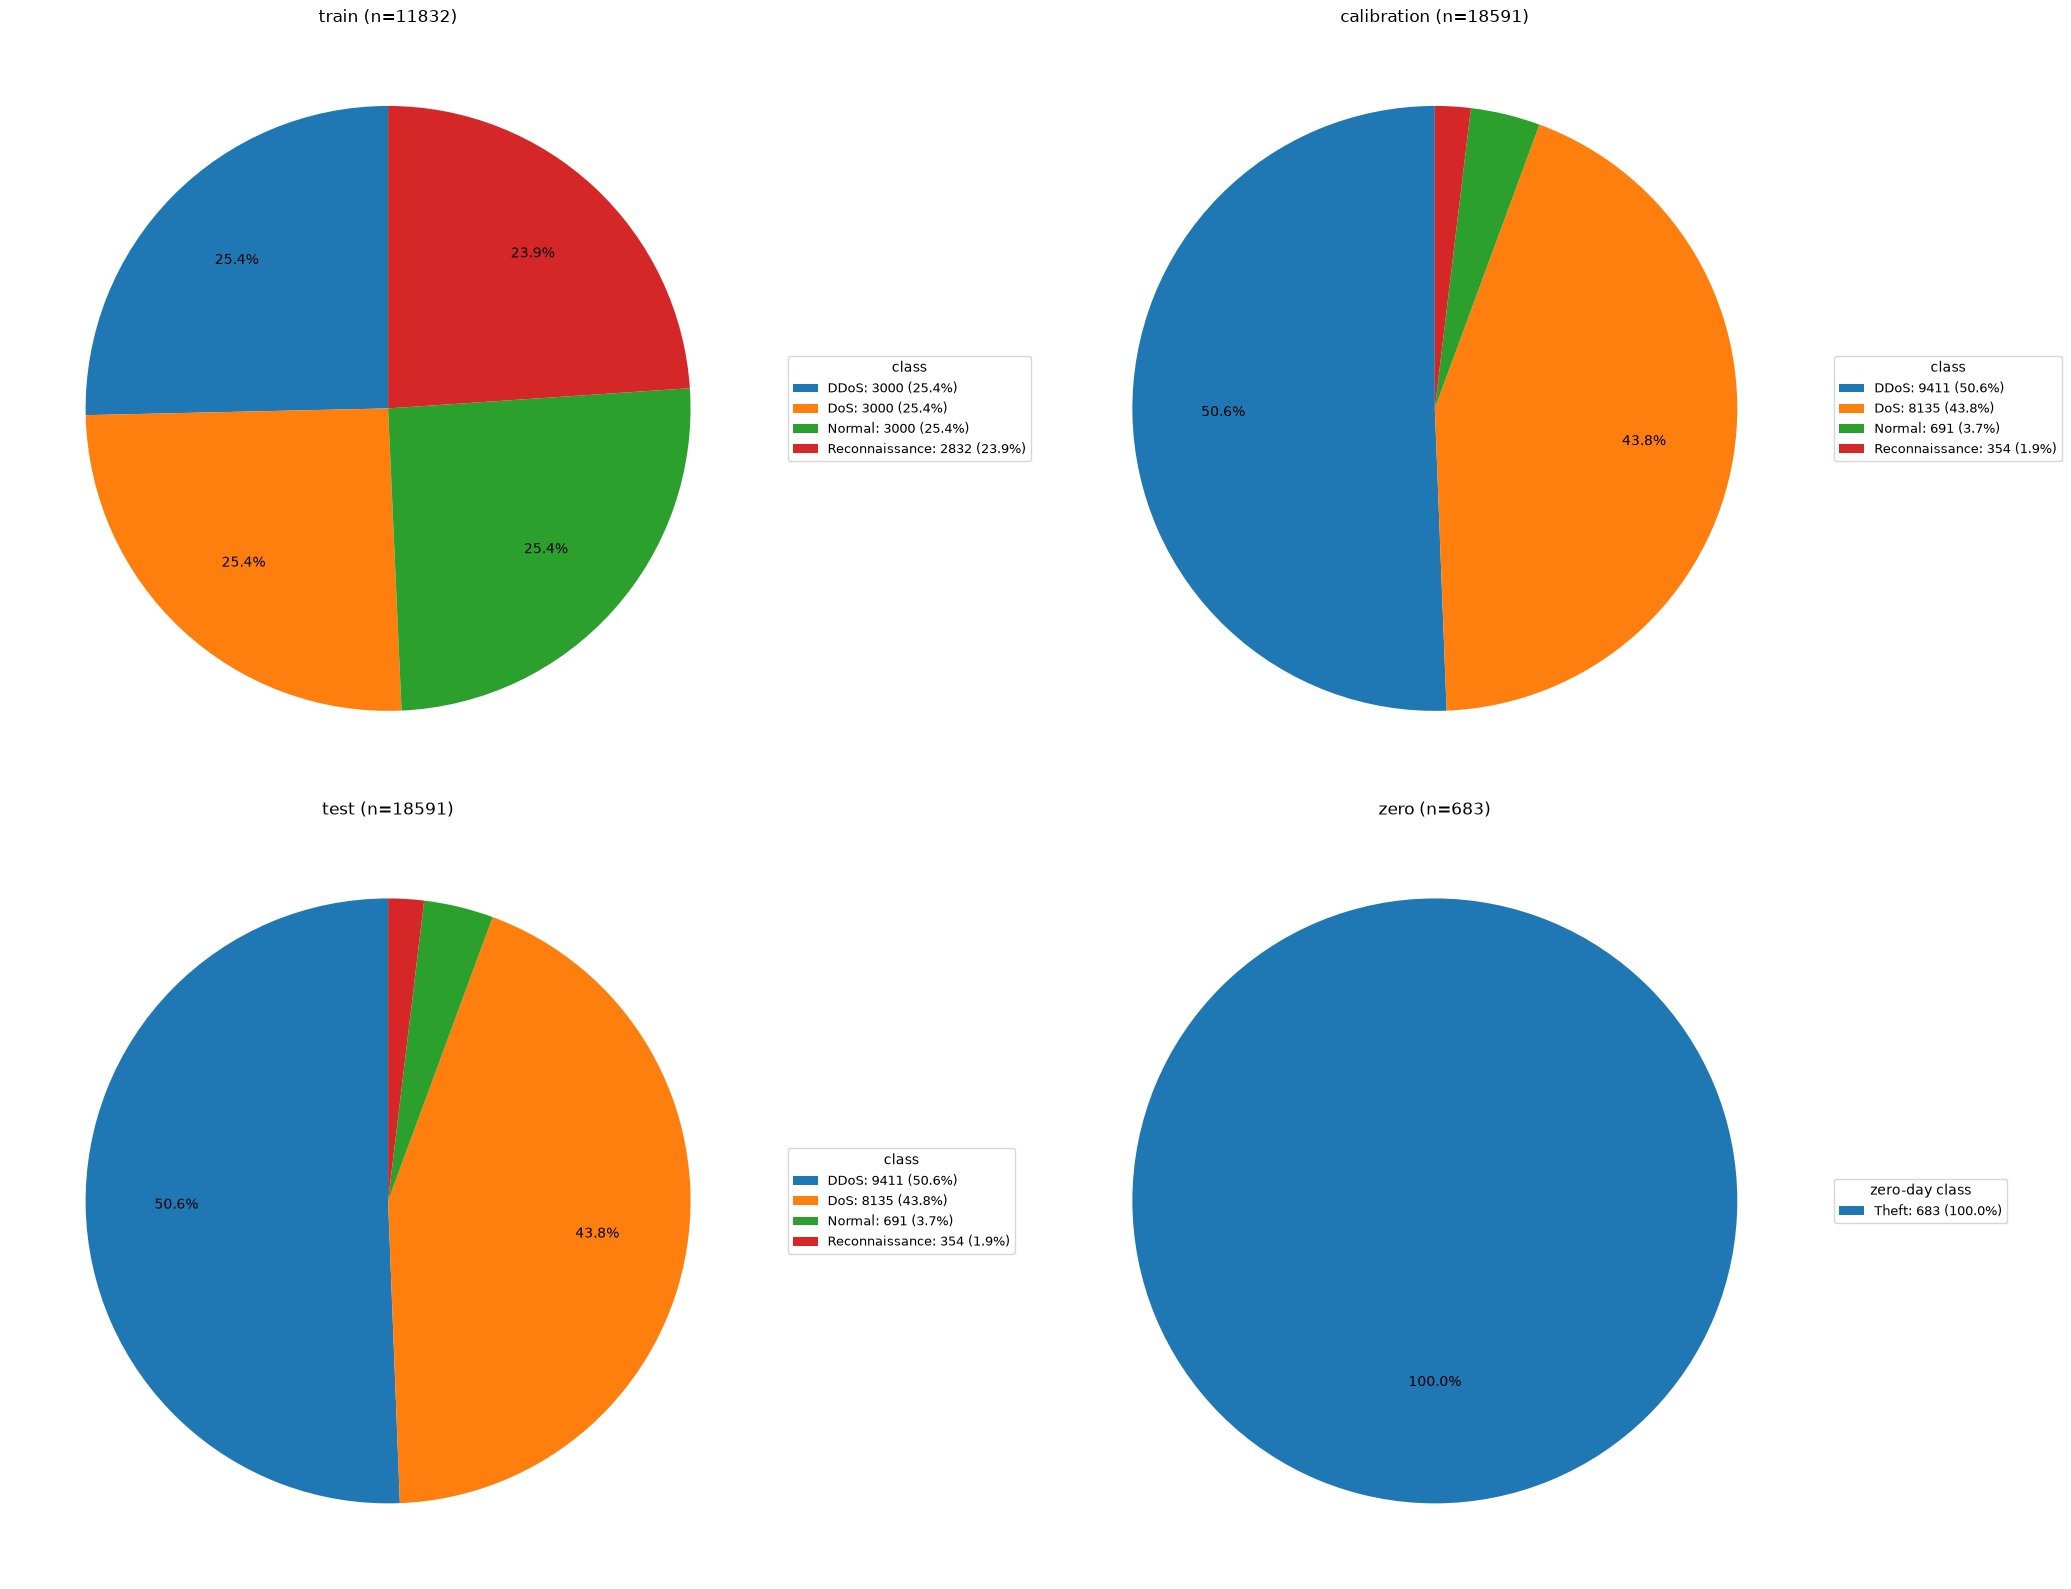

In [10]:
num_classes = len(class_names)
print(f"number of classes: {num_classes}")

splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

ax = axes[len(splits)]
vc = df_zero_subset[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero_subset)})")

for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Load Day-23 FROZEN Checkpoint

Reuse $\theta^\star$, prototypes, and the train-fitted scaler / PCA / angle bounds from Day-23.


In [11]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY23_NOTEBOOK}-checkpoint.pt",
]

batch_size = DEFAULT_BATCH_SIZE
seed = SEED

In [12]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

if not (LOAD_CHECKPOINT and ckpt_path is not None):
    raise FileNotFoundError(
        f"Day-23 checkpoint not found under {CHECKPOINT_CANDIDATES}. "
        f"Publish it from {DAY23_NOTEBOOK}_(final).ipynb first."
    )

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

theta_star = ckpt["theta"]
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)

prototypes = {int(k): v for k, v in ckpt["prototypes"].items()}
class_names = list(ckpt.get("class_names", class_names))
num_classes = int(ckpt.get("num_classes", len(class_names)))
num_qubits = int(ckpt["num_qubits"])
num_layers = int(ckpt.get("num_layers", 2))
noise_rate = float(ckpt.get("noise_rate", DEFAULT_NOISE_RATE))

scaler = ckpt["scaler"]
pca = ckpt.get("pca")
USE_PCA = bool(ckpt.get("use_pca", pca is not None))
x_min = np.asarray(ckpt["angle_x_min"])
x_max = np.asarray(ckpt["angle_x_max"])
angle_max = float(ckpt.get("angle_max", np.pi))
k95 = int(ckpt.get("k95", num_qubits))

if "head_state_dict" in ckpt:
    head = torch.nn.Linear(num_qubits, num_classes)
    head.load_state_dict(ckpt["head_state_dict"])

print(f"loaded checkpoint: {ckpt_path}")
print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")
print(f"num_qubits={num_qubits} | num_layers={num_layers} | USE_PCA={USE_PCA} | k95={k95}")
print(f"feature_cols: {len(ckpt.get('feature_cols', FEATURE_COLS))}")

loaded checkpoint: artifacts/BoT-IoT/4class-3000each-lr0.05-maqt-checkpoint.pt
theta shape: (2, 5, 3) | prototypes: 4
num_qubits=5 | num_layers=2 | USE_PCA=True | k95=5
feature_cols: 10


## Mapping Features $\rightarrow$ [0, $\pi$]


angles cal/test/zero: (18591, 5), (18591, 5), (683, 5) | USE_PCA=True


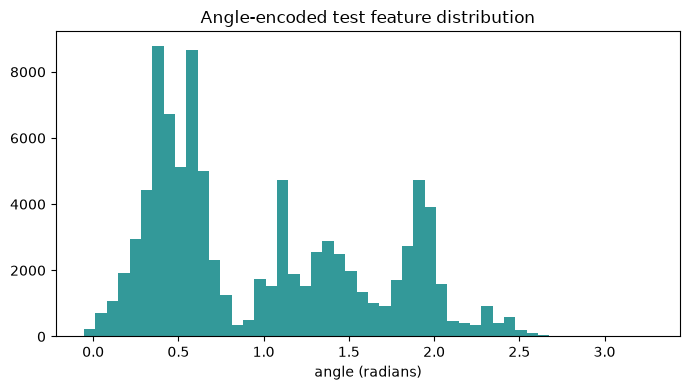

In [13]:
# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
pca_for_angles = pca if USE_PCA else None
X_cal_angles = to_angles(X_cal, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)
X_test_angles = to_angles(X_test, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)
X_zero_angles = to_angles(X_zero, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)
X_train_angles = to_angles(X_train, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)

print(f"angles cal/test/zero: {X_cal_angles.shape}, {X_test_angles.shape}, {X_zero_angles.shape} | USE_PCA={USE_PCA}")

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_test_angles.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded test feature distribution")
plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$$
x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)
$$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [14]:
print(f"num_qubits={num_qubits} (from Day-23) | num_layers={num_layers} | noise_rate={noise_rate}")

num_qubits=5 (from Day-23) | num_layers=2 | noise_rate=0.01


In [15]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits)  # or qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# move model tensors to device
theta_star = theta_star.to(device)
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)
prototypes = {int(k): v.to(device) for k, v in prototypes.items()}
if head is not None:
    head = head.to(device)

print(f"device={device}")

device=cuda


## Lipschitz Bound $L_\varphi$ (Analytic R/2)

**Lemma 1**: For angle encoding with data reupload, $L_\varphi = R/2$ with $R=$ `num_layers`.

In [16]:
L_phi = analytic_lipschitz_bound(num_layers, reupload=True)
lphi_path = None
print(f"using analytic L_phi=R/2={L_phi:.4f} (num_layers={num_layers})")

using analytic L_phi=R/2=1.0000 (num_layers=2)


## Conformal Zero-Day Threshold Calibration (q)

- Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.
- Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

Recalibrate $q$ on Day-23 angle-encoded $X_{\mathrm{cal}}$.

In [17]:
alpha = DEFAULT_ALPHA

In [18]:
q, scores_sorted = calibrate_threshold(
    theta_star, X_cal_angles, prototypes, forward_circuit,
    alpha=alpha, device=device, batch_size=batch_size,
)
q_source = "calibrate_threshold(X_cal) on Day-23 checkpoint"
print(f"calibrated q={q:.6f} (alpha={alpha}, n_cal={len(X_cal_angles)})")

calibrated q=0.301439 (alpha=0.05, n_cal=18591)


## Evaluation on Training Samples Themselves

In [19]:
Cf = DEFAULT_CF
zero_day = ZERO_DAY
p = noise_rate

print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"C_f     : {Cf}")
print(f"q       : {q:.6f}")

p       : 0.01
L_phi   : 1.0000
C_f     : 1.0
q       : 0.301439


In [20]:
y_pred, radii, novelty_scores, f_maps = qsnet_infer_batch(
    X_train_angles, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)
y_train_np = to_np_y(y_train).astype(int)
label_ids = list(range(num_classes))

[train] mean certified radius (accepted): 0.0375
[train] reject rate (known): 0.1105 | acc (accepted): 0.5769

[train] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.56      0.24      0.34      2814
           DoS       0.43      0.82      0.57      2944
        Normal       1.00      0.18      0.30      2025
Reconnaissance       0.77      0.96      0.86      2741

      accuracy                           0.58     10524
     macro avg       0.69      0.55      0.52     10524
  weighted avg       0.67      0.58      0.53     10524



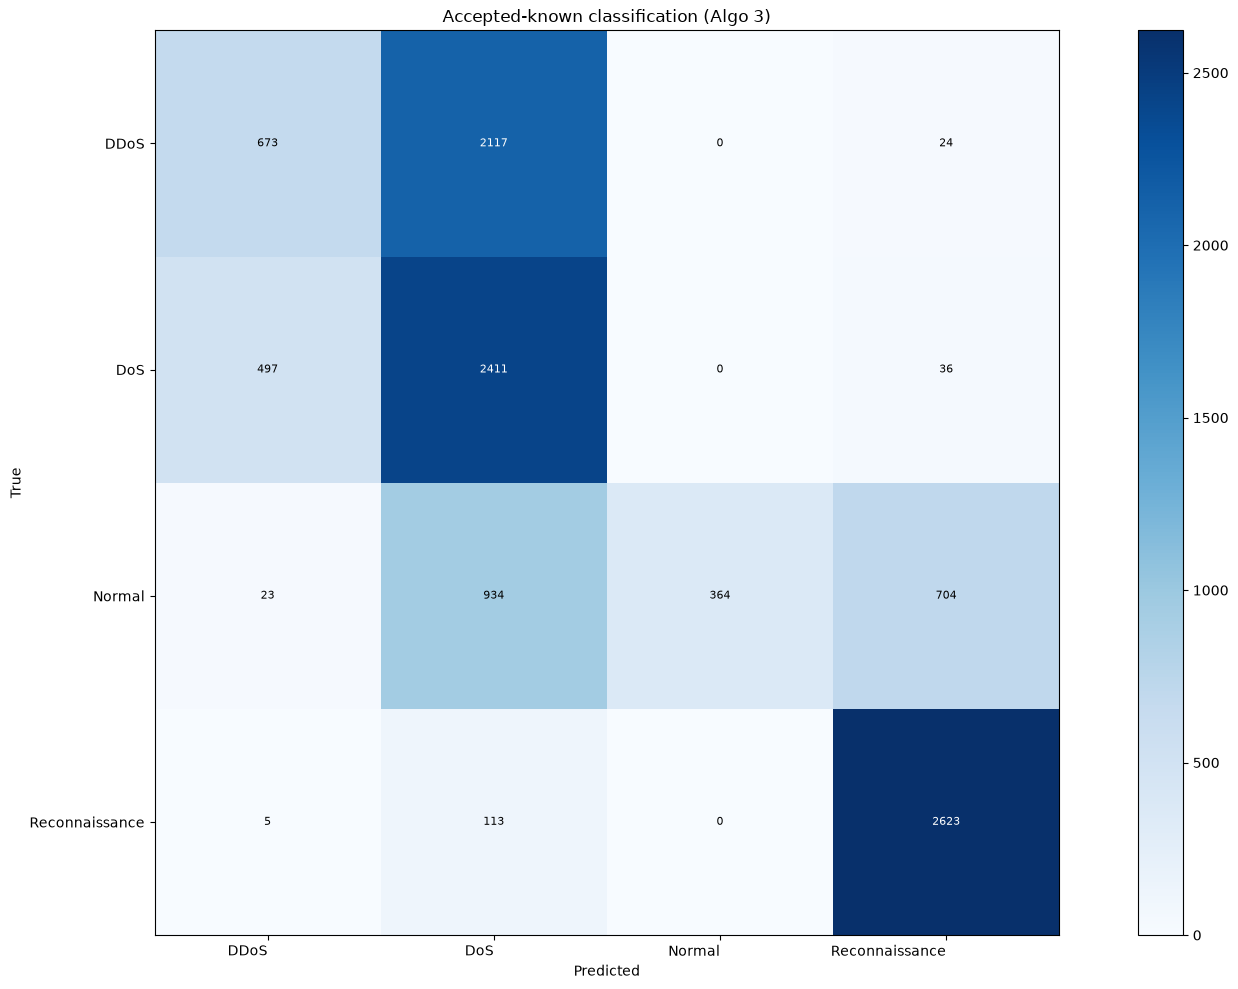

In [21]:
known_mask = y_pred != ZERO_DAY
pipeline_reject_rate = float(1.0 - known_mask.mean())
pipeline_acc = float(np.mean(y_pred[known_mask] == y_train_np[known_mask])) if known_mask.any() else 0.0
pipeline_macro_f1 = float(
    f1_score(y_train_np[known_mask], y_pred[known_mask], average="macro", labels=label_ids, zero_division=0)
)
pipeline_radius_mean = float(radii[known_mask].mean()) if known_mask.any() else float("nan")

print(f"[train] mean certified radius (accepted): {pipeline_radius_mean:.4f}")
print(f"[train] reject rate (known): {pipeline_reject_rate:.4f} | acc (accepted): {pipeline_acc:.4f}")

if known_mask.any():
    print("\n[train] classification report (accepted only):")
    print(classification_report(
        y_train_np[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_train_np[known_mask], y_pred[known_mask], labels=label_ids)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3)",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Known Test Samples


In [22]:
y_pred, radii, novelty_scores, f_maps = qsnet_infer_batch(
    X_test_angles, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)
y_test_np = to_np_y(y_test).astype(int)
label_ids = list(range(num_classes))

[test] mean certified radius (accepted): 0.0125
[test] reject rate (known): 0.0472 | acc (accepted): 0.5174

[test] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.62      0.25      0.35      8868
           DoS       0.49      0.82      0.61      8024
        Normal       1.00      0.16      0.27       475
Reconnaissance       0.52      0.95      0.67       346

      accuracy                           0.52     17713
     macro avg       0.66      0.54      0.48     17713
  weighted avg       0.57      0.52      0.47     17713



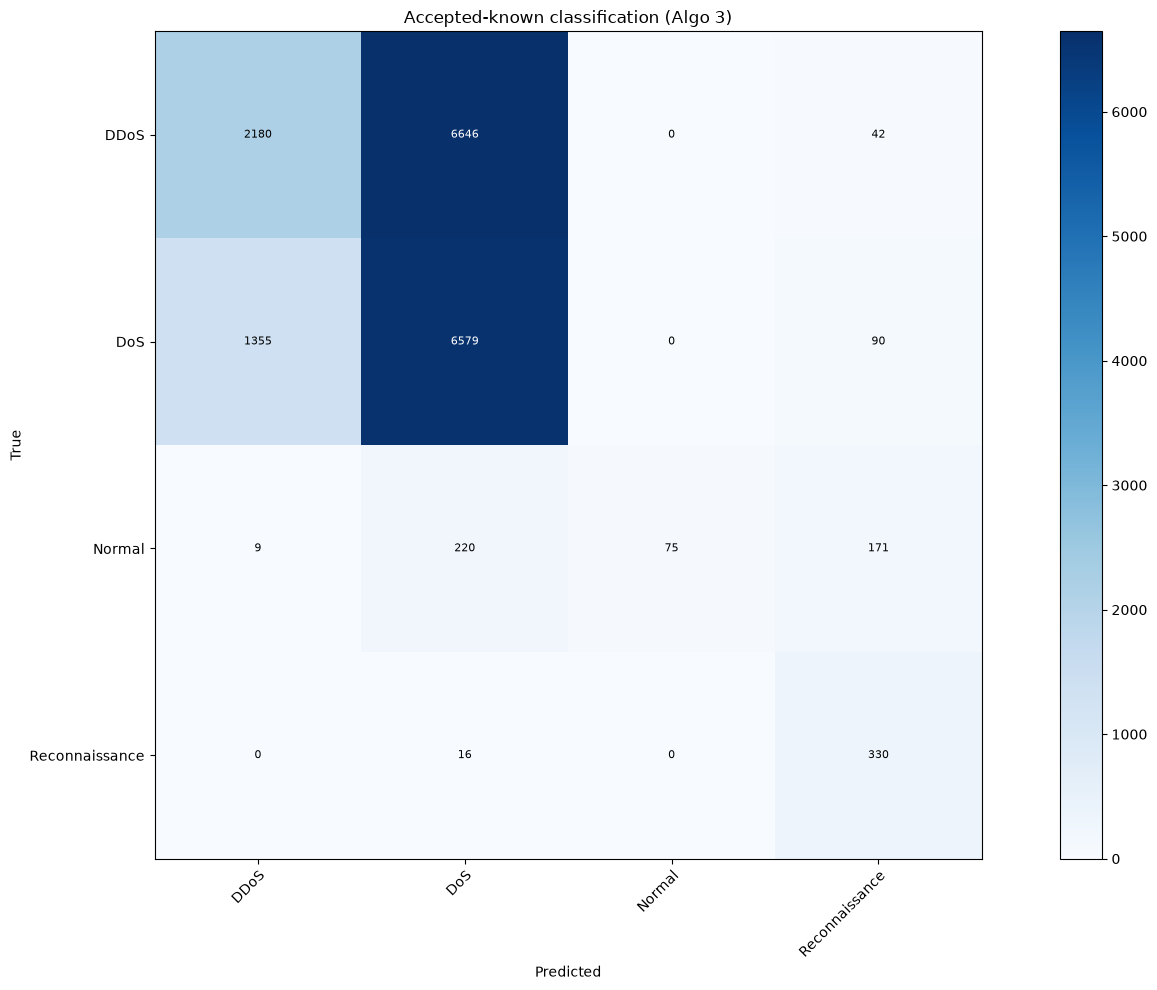

In [23]:
known_mask = y_pred != ZERO_DAY
pipeline_reject_rate = float(1.0 - known_mask.mean())
pipeline_acc = float(np.mean(y_pred[known_mask] == y_test_np[known_mask])) if known_mask.any() else 0.0
pipeline_macro_f1 = float(
    f1_score(y_test_np[known_mask], y_pred[known_mask], average="macro", labels=label_ids, zero_division=0)
)
pipeline_radius_mean = float(radii[known_mask].mean()) if known_mask.any() else float("nan")

print(f"[test] mean certified radius (accepted): {pipeline_radius_mean:.4f}")
print(f"[test] reject rate (known): {pipeline_reject_rate:.4f} | acc (accepted): {pipeline_acc:.4f}")

if known_mask.any():
    print("\n[test] classification report (accepted only):")
    print(classification_report(
        y_test_np[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test_np[known_mask], y_pred[known_mask], labels=label_ids)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Zero-Day Samples

In [24]:
df_zero_subset.head(3)

,n_pkts_total,n_bytes_total,src_bytes,rate,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,protocol,conn_state,label_multiclass
0,-1.441506,-1.957766,-3.072331,46.901080,0.000126,-0.863721,-0.609612,-0.274325,-1.0,-1.306571,Theft
1,-1.441506,-1.957766,-3.072331,47.759378,0.000108,-0.863728,-0.609621,-0.274325,-1.0,-1.306571,Theft
2,-1.441506,-1.957766,-3.072331,47.888686,0.000106,-0.863728,-0.609622,-0.274325,-1.0,-1.306571,Theft


In [25]:
y_zero_pred, radii_zero, scores_zero, _ = qsnet_infer_batch(
    X_zero_angles, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)

detected = y_zero_pred == ZERO_DAY
detection_rate = float(detected.mean())

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero_angles)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

detected as ZERO_DAY: 158 / 683 (23.1%)
incorrectly accepted: 525
mean novelty score: 0.2336 | threshold q: 0.3014


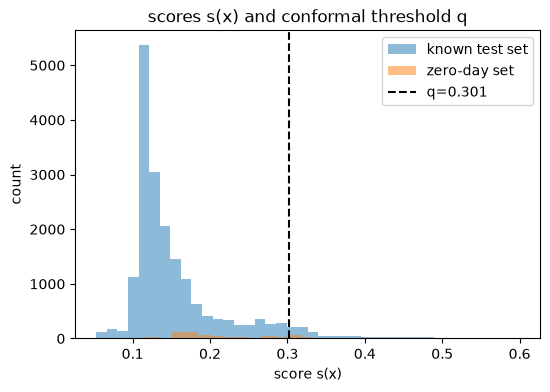

In [26]:
plt.figure(figsize=(6, 4))
plt.hist(novelty_scores, bins=40, alpha=0.5, label="known test set")
plt.hist(scores_zero, bins=30, alpha=0.5, label="zero-day set")
plt.axvline(q, color="k", linestyle="--", label=f"q={q:.3f}")
plt.legend()
plt.xlabel("score s(x)")
plt.ylabel("count")
plt.title("scores s(x) and conformal threshold q")
plt.show()

## RQ1 Detection Numbers


In [27]:
TPR_zeroday = float(detection_rate)
FPR_known = float(pipeline_reject_rate)
class_acc_known = float(pipeline_acc)

print("=== RQ1 ===")
print(f"True Positive Rate (TPR_zeroday):  {TPR_zeroday:.4f}          # fraction of true zero-day rejected")
print(f"False Positive Rate (FPR_known):   {FPR_known:.4f}          # fraction of known wrongly rejected (target alpha={alpha})")
print(f"Accepted-known accuracy (class_acc_known): {class_acc_known:.4f}  # class accuracy on known samples Algo-3 accepted")
print(f"n_test={len(y_test_np)}")
print(f"n_zeroday={len(X_zero_angles)}")

=== RQ1 ===
True Positive Rate (TPR_zeroday):  0.2313          # fraction of true zero-day rejected
False Positive Rate (FPR_known):   0.0472          # fraction of known wrongly rejected (target alpha=0.05)
Accepted-known accuracy (class_acc_known): 0.5174  # class accuracy on known samples Algo-3 accepted
n_test=18591
n_zeroday=683


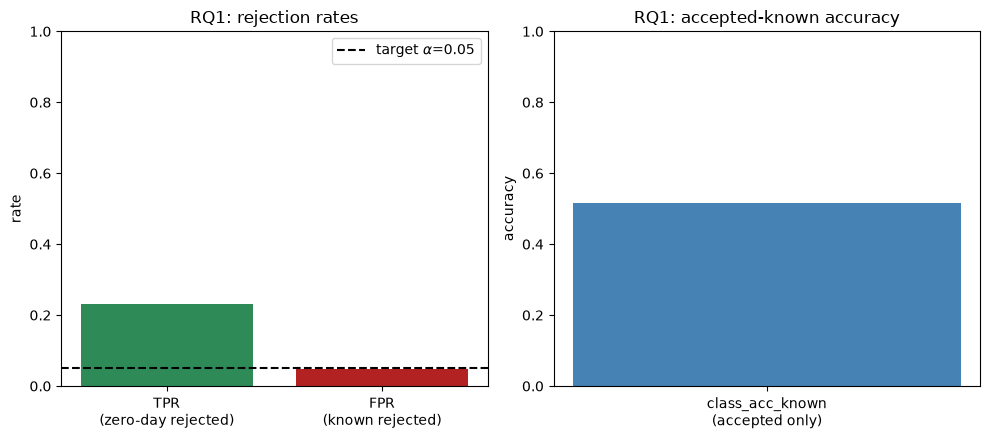

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(
    ["TPR\n(zero-day rejected)", "FPR\n(known rejected)"],
    [TPR_zeroday, FPR_known],
    color=["seagreen", "firebrick"],
)
axes[0].axhline(alpha, color="black", linestyle="--", label=fr"target $\alpha$={alpha}")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("rate")
axes[0].set_title("RQ1: rejection rates")
axes[0].legend()

axes[1].bar(["class_acc_known\n(accepted only)"], [class_acc_known], color="steelblue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("accuracy")
axes[1].set_title("RQ1: accepted-known accuracy")

plt.tight_layout()
plt.show()

## Logging


In [29]:
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "lphi_path": lphi_path,
    "L_phi_source": "analytic_lipschitz_bound (R/2)",
    "q_source": q_source,
    "q": float(q),
    "alpha": float(alpha),
    "L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "use_pca": bool(USE_PCA),
    "num_qubits": int(num_qubits),
    "num_layers": int(num_layers),
    "pipeline_reject_rate": float(pipeline_reject_rate),
    "pipeline_acc_accepted": float(pipeline_acc),
    "pipeline_macro_f1_accepted": float(pipeline_macro_f1),
    "pipeline_radius_mean_accepted": float(pipeline_radius_mean),
    "zeroday_detection_rate": float(detection_rate),
    "n_zeroday_eval": int(len(X_zero)),
    "RQ1": {
        "TPR_zeroday": TPR_zeroday,
        "FPR_known": FPR_known,
        "class_acc_known": class_acc_known,
        "alpha": float(alpha),
        "n_test": int(len(y_test_np)),
        "n_zeroday": int(len(X_zero)),
    },
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}.pt").resolve())

write_history_log(
    history if history else {"radius_mean": [pipeline_radius_mean]},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)

published: /home/lawun330/Desktop/quantum-sentinel/artifacts/BoT-IoT/4class-3000each-lr0.05-algo3.pt


PosixPath('logs/4class-3000each-lr0.05-algo3.log')